In [62]:
from pathlib import Path
import matplotlib.pyplot as plt 
import pandas as pd

# Dateipfade festlegen
VENV_DIR = Path.cwd()
DATA_DIR = VENV_DIR / 'Daten'

# 1. Versuchsaufbau 

Um eine automatisierte Bewässerung zu realisieren, muss Wasser zum Gießen aus einem Reservoir in das Beet befördert werden. Der schematische Aufbau ist in Abbildung 1 zu sehen. Dazu wird eine 12 V DC Pumpe verwendet, die mittels eines 3,3V Relais angesteuert wird und 12 l/min fördern kann. Die Pumpe wird unterhalb des Wasserbehälters positioniert, damit die Saugleitung der Pumpe bei jedem Füllstand vollständig mit Wasser gefüllt ist. Versuche haben gezeigt, dass die Pumpe nicht in der Lage ist bei einer größeren Luftblase in der Saugleitung noch Wasser zu fördern. Wenn der Sollwert unterschritten wird und die Pumpe laufen soll, muss sichergestellt sein, dass die komplette Leitung mit Wasser gefüllt ist. Ansonsten würde sich die Wassersäule immer mit dem Füllstand des Behälter ausgleichen und der Förderweg variieren. Der idealste Fall wäre wenn die Wassersäule stehen bleiben würde und die Druckleitung immer nahezu komplett mit Wasser gefüllt wäre. Dazu wird ein Rückschlagventil in den Fließweg eingebaut, das ein Abfallen der Wassersäule verhindert.  

<div style="display: flex; justify-content: space-around; align-items: center;">
    <figure style="text-align: center;">
    <img src='Bilder/Aufbau_Schema.png' alt='Schema' width='200%'> 
    <figcaption><i>Abb. 1: Schematischer Aufbau</i></figcaption>
    </figure>
    <figure style="text-align: center;">
    <img src='Bilder/Pump.jpeg' alt='Pumpe' width='35%'> 
    <figcaption><i>Abb. 2: 12V DC Pumpe</i></figcaption>
    </figure>
</div>

Für den Wasserbehälter wird ein durchsichtiger Kunststoffkanister verwendet, sodass man den Füllstand einsehen kann und von oben nachfüllen kann. Der Behälter muss oben geöffnet bleiben, damit bei Betrieb der Pumpe kein Unterdruck entsteht.  
Für die Verteilung des Wassers im Beetkasten wird ein Schlauch mit 13 mm Innendurchmesser verwendet. In diesen werden im Bereich des Beetes in längsrichtung Löcher eingebracht aus denen das Wasser austreten kann.

## 1.1 Mikrocontroller
Das Herz des Aufbaus bildet der ESP32-Mikrocontroller. Auf diesen werden die Programme geflasht und können ausgeführt werden. Hier werden die Sensoren und Aktoren angeschlossen und Messwerte können ausgelesen, umgerechnet und gespeichert werden. 

<div align=center>
    <figure>
    <img src='Bilder/Microcontroller.jpeg' alt='ESP32' width='25%'> 
    <figcaption><i>Abb. 2: Mikrocontroller ESP32 </i></figcaption>
    </figure>
</div>


### 1.1.1 Micropython
Zur Programmierung wurde [Micropython](https://micropython.org) verwendet. Dabei handelt es sich um eine an Python angelehnte Programmiersprache, welche größtenteils mit dem Standardpython kompatibel ist. So ist ein schneller Austausch von Programmen von Computer zu Microcontroller möglich.  
Um Micropython auf dem ESP32 zu verwenden muss die passende Firmware auf den Microcontroller *geflasht* werden. Diese steht für eine Vielzahl von Microcontrollern auf der Micropython Webseite zum Download bereit. Der ESP32 kann dann mittels USB-C Kabels mit dem Rechner verbunden werden und über das Terminal bzw. den Windows Command Prompt (*cmd*) kann die Firmware geflasht werden. Eine detaillierte Anleitung findet man [hier](https://micropython.org/download/ESP32_GENERIC/).  
Danach kann mit einer geeigneten IDE Programmcode auf dem ESP32 ausgeführt werden. Wir haben hier größtenteils mit der Thonny IDE und Visual Studio Code gearbeitet.

## 1.2 Bodenfeuchtesensor
Zur Messung der Bodenfeuchte wird ein kapazitiver Feuchtigkeitssensor eingesetzt. Dieser wird senkrecht in den Boden eingebracht. Das Wasser fungiert bei einem kapazitiven Sensor als Dielektrikum zwischen den Platten des Kondensator und besitzt eine deutlich größere Dielektrizitätszahl $\varepsilon_r$ als trockene Erde. Je mehr Wasser zwischen zwischen den Platten vorhanden ist, desto höher ist die Kapazität des Kondensators. Diese kann letztendlich gemessen werden. Die Bodenfeuchte soll später als eine mögliche Regelgröße für die Pumpe dienen. 

<div align=center>
    <figure>
    <img src='Bilder/Feuchtesensor.jpeg' alt='Bodenfeuchtesensor' style="transform: rotate(180deg);" width=25%>
    <figcaption><i>Abb. 3: Kapazitiver Bodenfeuchtesensor </i></figcaption>
    </figure>
</div>

### 1.2.1
Damit der Sensor genaue Werte liefert, wird dieser in der verwendeten Erde kalibriert. Anschließend wird daraus eine Funktion abgeleitet, welche in den Programmcode hinterlegt wird. Die Werte wurden mithilfe einer Erdprobe, zwei Bechern und einer Küchenwaage durchgeführt. Die Blumenerde wurde vorher im Backofen kurz durchgetrocknet. Danach wurde der Sensorwert bei vollkommen trockener Erde ermittelt. Dann werden sukzessive 20 ml Wasser in die Erde gegossen und jedes mal die Werte aufgenommen. Es wurden bei jeder Stufe jeweils zehn Werte aufgenommen und gemittelt. Mittels ```scipy.optimize``` werden aus den Datenpunkten die Parameter einer Polynomfunktion bestimmt. Diese Funktion konnte dann im Code auf den ESP32 eingesetzt werden.  

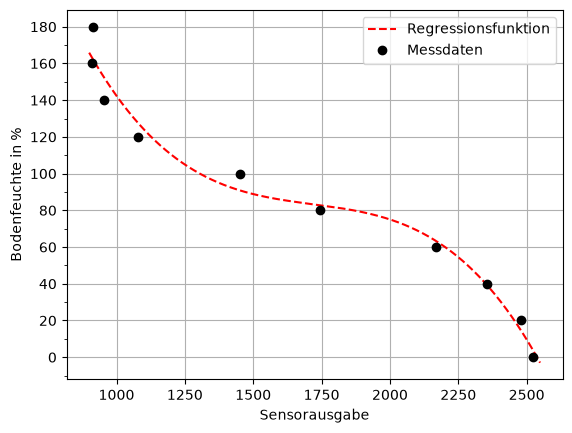

In [66]:
from scipy.optimize import curve_fit

sensor = pd.read_excel(DATA_DIR / 'Kalibrierung_Feuchtesensor.xlsx', sheet_name='v1.2_csv', index_col=0)
mittel = sensor.groupby(sensor.index)['Messwerte'].mean()

def func_sensor(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

rohwert = mittel.to_numpy()
moisture = mittel.index.to_numpy()
popt, _ = curve_fit(func_sensor, rohwert, moisture)

y = [func_sensor(i, *popt) for i in range(900, 2550)]

fig, ax = plt.subplots()

ax.plot(range(900, 2550), y, label='Regressionsfunktion', ls='--', c='r')
ax.plot(rohwert, moisture, label='Messdaten', ls='', marker='o', c='k')
ax.grid(True)
ax.yaxis.set_minor_locator(plt.MultipleLocator(10))
ax.yaxis.set_major_locator(plt.MultipleLocator(20))
ax.set_xlabel('Sensorausgabe')
ax.set_ylabel('Bodenfeuchte in %')
ax.legend()
plt.show()

## 1.3 Umgebungsdaten
Zur Datensammlung sollen auch die Umgebungstemperatur, -feuchte und -Druck gemessen werden. Hierzu wird ein Bosch BME280 eingesetzt. Dieser Sensor kann alle drei Werte messen. Die Messgenauigkeiten finden sich in Tabelle 1. Der Sensor kommuniziert mit dem ESP32 über eine $\mathrm{I^2C}$ Verbindung. Die Initialisierung der Sonsoren erfolgt dann über ein Skript in Micropython, welches auf den ESP32 geflasht wird.

<div align=center>
    <figure>
    <img src='Bilder/BME280.jpeg' alt='BME280' width='25%'> 
    <figcaption><i>Abb. 4: Platine mit BME280 Sensor</i></figcaption>
    </figure>
</div>

<div align="center">
    <b>Tab. 1: Messspezifikationen und Genauigkeiten des BME280 Sensors</b>
</div>

| Sensor-Parameter | Messbereich | Absolute Genauigkeit (Tolerance) | Relative Genauigkeit (Präzision) |
| :--- | :--- | :--- | :--- |
| **Luftdruck** | 300 ... 1100 hPa | $\pm$ 1,0 hPa (0 bis +65 °C) | $\pm$ 0,12 hPa |
| **Temperatur** | -40 ... +85 °C | $\pm$ 0,5 °C (bei 25 °C) | - |
| **Luftfeuchtigkeit** | 0 ... 100 % r.H. | $\pm$ 3 % relative Feuchte | -|

#### 1.3.1 Wetterdaten API
Zur Datenabfrage wird eine API-Schnittstelle vom Wetterdienst **OpenWeather** genutzt und in den Code implementiert. Um eine Request an die API stellen zu können, muss auf der Webseite von [OpenWeather](https://openweathermap.org/api) ein API-Key angefordert werden. Für eine Anfrage wird das Python Paket ```requests``` verwendet.

In [ ]:
import requests

Der eigentliche Aufruf wird über eine URL durchgeführt. Diese kann den [API Docs](https://openweathermap.org/api/one-call-4?collection=one_call_api#current) entnommen werden. In die URL werden die Koordinaten des gewünschten Standortes sowie ein gültiger API Key eingetragen. Die geographischen Koordinaten des Standortes wurden bei Google Earth entnommen. Die Längen- (Longitude) und Breitengrade (Latidude) mussten allerdings für die URL in Dezimalgrad umgerechnet werden mit folgender Formel: $$ DD = \text{Dezimalgrad} + \frac{\text{Minuten}}{60} + \frac{\text{Sekunden}}{3600} $$ Dazu wurde eine Funktion geschrieben die diese Umrechung übernimmt.

In [2]:
def gms_to_degree(degree, minutes, seconds, direction):
    '''
    Umrechung von 51°58'38.93"N zu Dezimalgrad für Longitude (Längengrad) und Latidude (Breitengrad)
    '''
    dd = float(degree) + float(minutes)/60 + float(seconds)/3600
    if direction in ['S', 'W']:
        dd *= -1
    return dd

So kann die Abfrage für die Wetterdaten durchgeführt werden

In [69]:
API_KEY = '957ce3f15b719431e622d38d78c397af'

lat_gms = (51, 58, 38.93, 'N') # Breitengrad als Gradminuten
lon_gms = (7, 33, 53.08, 'E') # Längengrad als Gradminuten

# Umrechung in Dezimalgrad
lat = gms_to_degree(*lat_gms)
lon = gms_to_degree(*lon_gms)

# Ausgabeeinheiten in metrische Einheiten festlegen
unit = 'metric' 

# Adresse zur Abfrage
url = f'https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}&units={unit}'

# Abrage über requests
response = requests.get(url) # erzeugt Responseobjekt mit der Antwort des Servers type -> <class 'requests.models.Response'>
data = response.json() # Server schickt Antwort als json. Hier wird die json decoded, type -> <class 'dict'>
print(data)

{'coord': {'lon': 7.5647, 'lat': 51.9775}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 23.17, 'feels_like': 22.9, 'temp_min': 22.81, 'temp_max': 23.17, 'pressure': 1014, 'humidity': 52, 'sea_level': 1014, 'grnd_level': 1007}, 'visibility': 10000, 'wind': {'speed': 3.09, 'deg': 70}, 'clouds': {'all': 100}, 'dt': 1787670516, 'sys': {'type': 2, 'id': 52688, 'country': 'DE', 'sunrise': 1787632199, 'sunset': 1787682854}, 'timezone': 7200, 'id': 2862632, 'name': 'Nienberge', 'cod': 200}


Das Objekt ```data``` von einer json in ein Dictionary umgewandelt. In diesem Dictionary sind jede Menge Informationen enthalten die wir in unserem Versuch nicht benötigen. Deshalb werden diese gefiltert, sodass nur relevante Daten zurückbleiben die dann in unsere übergeorndete CSV mit den Messdaten geschrieben werden können.

In [4]:
temp = data['main']['temp']
pressure = data['main']['pressure']
humidity = data['main']['humidity']

## 1.4 Datenspeicherung
Wir speichern die Daten direkt auf dem ESP32. Beim Starten der Messung wird auf dem ESP32 ein Accesspoint erstellt. Somit ist es möglich sich über WLAN mit diesem zu verbinden. Um die Daten abzurufen ohne jedesmal die Messung unterbrechen und den ESP32 mit dem Computer verbinden zu müssen, werden die Daten auf einen Webserver hochgeladen und angezeigt. Mir einem Computer oder Smartphone können die Daten eingesehen werden und sich die bis dahin gefüllte CSV-Datei heruntergeladen werden.

<div align=center>
    <figure>
    <img src='Bilder/Webserver.png' alt='Webserver' width=50%>
    <figcaption><i>Abb. 5: Datenanzeige auf dem Webserver </i></figcaption>
    </figure>
</div>

Die Daten werden Temporär auf dem Arbeitsspeicher des ESP32 gespeichert. Um einen Datenverlust bei Stromausfall zu vermeiden werden die Daten viermal am Tag vom Arbeitsspeicher auf den dauerhaften Datenträger des gespeichert.

# 2 Datenstruktur & -typen
Die Messwerte aus den Sensoren werden auf dem ESP32 gespeichert. Die aktuellen Sensorwerte können auf einem Webserver eingesehen werden. Auf diesem Webserver kann auch die CSV Datei mit allen bisher aufgenommen Daten heruntergeladen werden. Die Sensorwerte des Bodenfeuchtesensors können in ein Spannungsignal umgerechnet werden. Durch die Kalibrierung wird eine Funktion abgeleitet mit der die jeweiligen Spannungen einer Feuchte zugeordnet werden können. Diese können dann als Floats in die CSV Datei geschrieben. Für den BME280 wird die dazu passende Bibliothek in Micropython verwendet mit der sich die Messwerte des Sensors ausgeben lassen kann. Hier wird in der Funktion, mit der man die Daten ausgibt, schon eine Umrechnung vom rohen Sensorwert auf einen lesbaren Float übernommen.  

Um die Messungen einem Zeitpunkt zuzuordnen wird beim Start der Messung die Zeit des Microcontrollers über das Internet synchronisiert und Zeitstempel im Format YYYY:mm:dd HH:MM:SS mitgeschrieben. Zurzeit ist geplant im Intervall von 15 Minuten Daten aufzunehmen.

# Explorative Datenanalyse


In [72]:
# Datensatz einladen
data_raw = pd.read_csv(DATA_DIR / 'sensor_data.csv', sep=',', encoding='utf-8')

# Datetimeindex festlegen
format = '%Y-%m-%d %H:%M:%S'
data_raw['datetime'] = pd.to_datetime(data_raw['datetime'], format=format)
data_raw = data_raw.set_index('datetime')

Wurde der Datensatz über den Webserver heruntergeladen, wurden dem Datensatz Datenlücken hinzugefügt bzw. einige Zeilen wurden mit leeren überschrieben. Für dieses Problem konnte vorerst keine Lösung gefunden werden. Deshalb wurde der Datensatz nur noch über direkte USB-Verbindung mit dem ESP32 heruntergeladen. Allerdings befinden sich nun im Datensatz einige Zeitstempel doppelt. Diese müssen gefilter und entfernt werden, da dem Dataframe sonst keine Frequenz hinzugefügt werden kann.

Da es Probleme bei der Datenerfassung gab, existiert zwischen dem 09.07. und 03.08. eine große Lücke. Diese wird bei ```.asfreq``` vorwärtsaufgefüllt.

In [90]:
delete_mask = (
    (data_raw.index.duplicated(keep=False)) &
    (data_raw.isna().any(axis=1))
)
data = data_raw[~delete_mask]

# Prbe wie viele NaN's übrig sind
data.isna().sum()

# Frequenz auf 15 min stellen
data = data.asfreq(freq='15min', method='ffill')

data.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 4819 entries, 2026-07-05 13:52:48 to 2026-08-24 18:22:48
Freq: 15min
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      4819 non-null   int64  
 1   humidity       4819 non-null   float64
 2   pressure       4819 non-null   float64
 3   pump_time      4819 non-null   float64
 4   soil_moisture  4819 non-null   float64
 5   temperature    4819 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 263.5 KB


Nachdem alle fehlerhaften Zeilen entfernt und die Frequenz festgelgt wurde, existieren keine NaN's mehr im Datensatz. Als nächstes können die Datenspalten visualisiert werden, um sich einen Überblick zu verschaffen. Die Spalte ```timestamp``` wird dabei erstmal vernachlässigt da diese sehr große werte enhält und die Skalierung stark verzerrt.

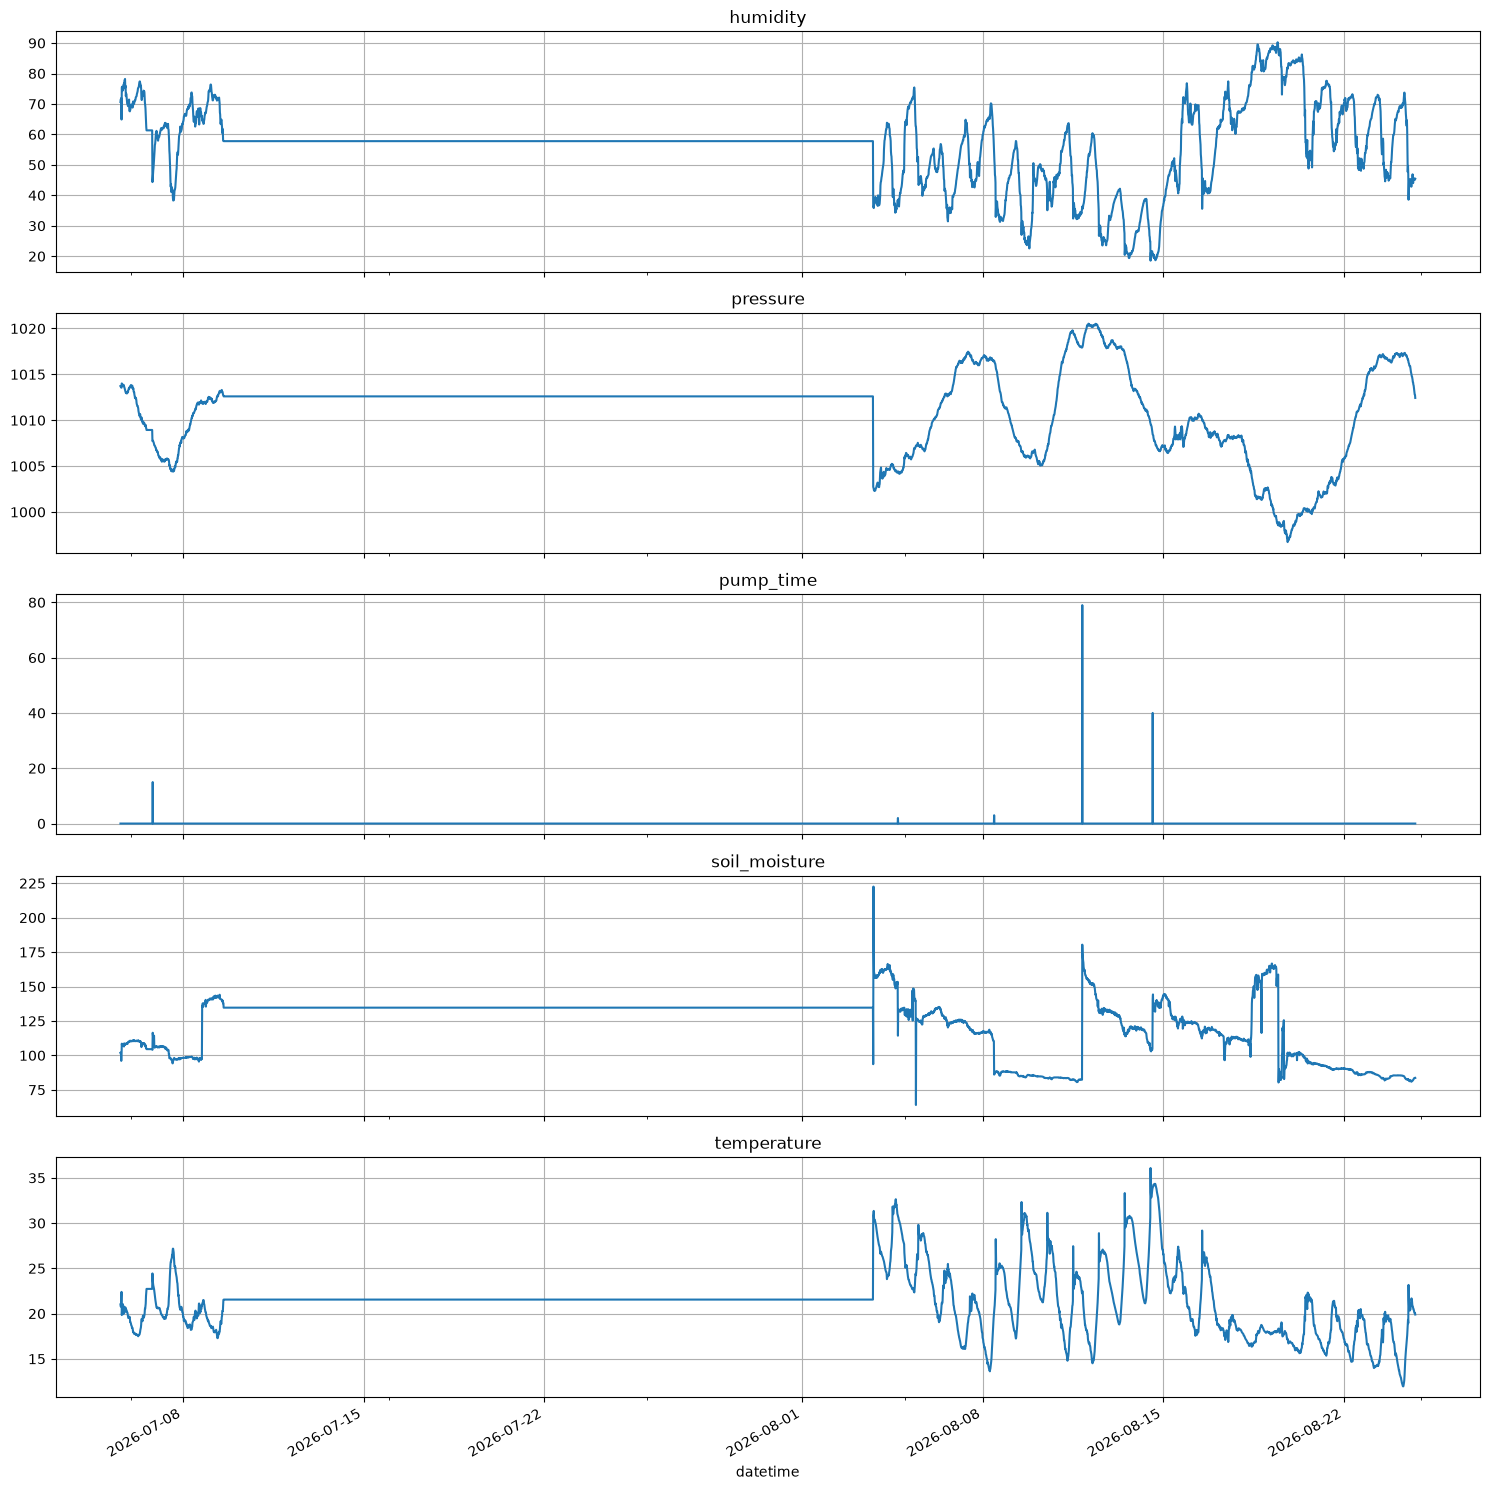

In [104]:
def plot_cols(df:pd.DataFrame, ignore= None):
    df = df.copy()
    if isinstance(ignore, str):
        ignore = [ignore]

    if ignore:
        df = df.drop(columns=ignore, errors=ignore)
        
    fig, ax = plt.subplots(len(df.columns), 1, figsize=(15, 3*len(df.columns)), sharex=True)
    for ax, col in zip(ax, df.columns):
        ax = df[col].plot(ax = ax)
        ax.set_title(col)
        ax.grid(True)

    fig.tight_layout()

plot_cols(data, ignore='timestamp')

Die Lücke wird hier deutlich über eine konstante Gerade in genannten Zeitraum. Zur besseren Sichtbarkeit wird die Betrachtung auf den rechten Bereich konzentriert und in einem neuen Dataframe ```data_aug``` gepeichert. Aus diesem werden dann alle Zeilen in denen sich der gleiche Timestamp befindet entfernt.

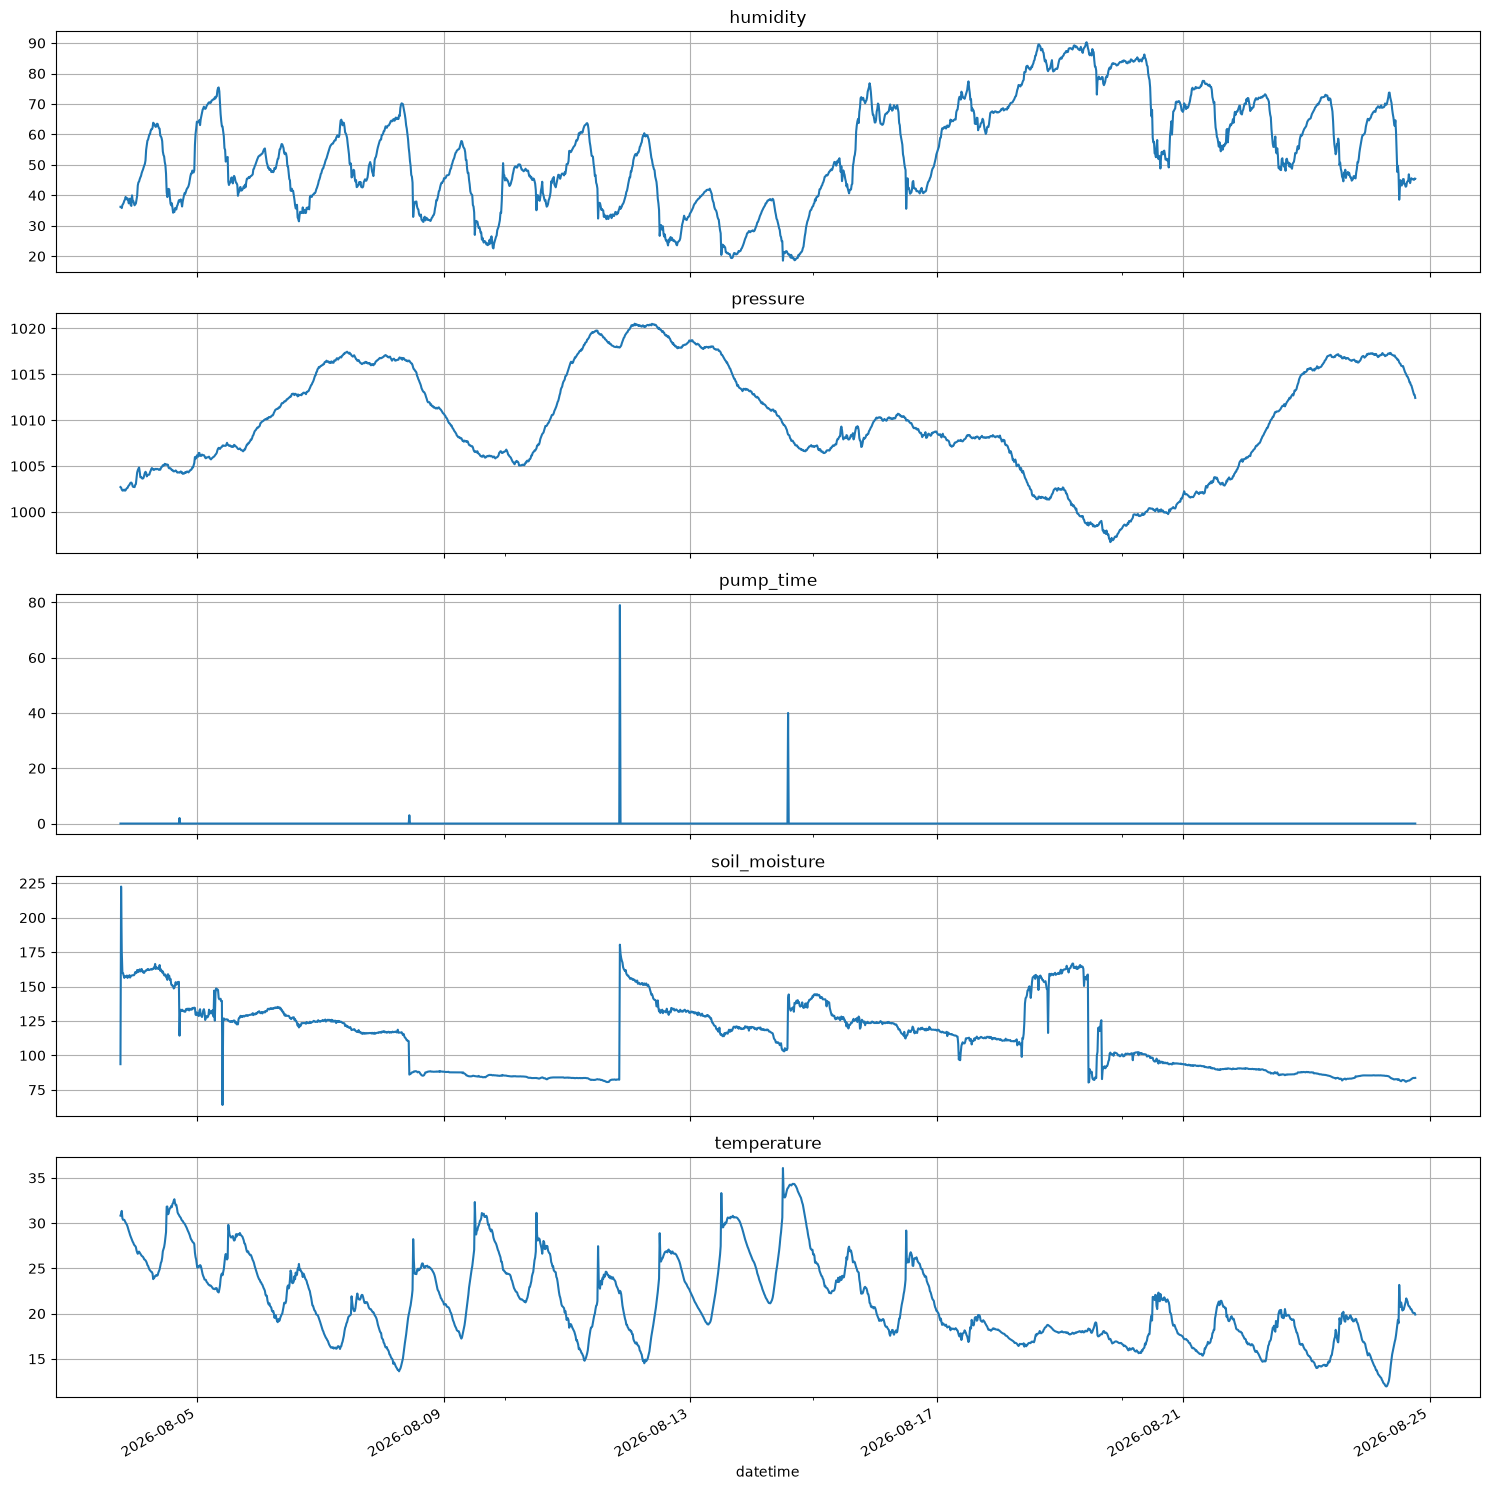

In [105]:
data_aug = data['2026-08-03':]
data_aug = data_aug[~data_aug.duplicated(keep=False)]

plot_cols(data_aug, ignore='timestamp')



In [106]:
from datetime import datetime

dt = int(datetime(2026, 8, 3, 0).timestamp())

url_history = f'https://api.openweathermap.org/data/3.0/onecall/timemachine?lat={lat}&lon={lon}&dt={dt}&appid={API_KEY}'

response = requests.get(url_history)
weather_history = response.json()
print(weather_history)

{'lat': 51.9775, 'lon': 7.5647, 'timezone': 'Europe/Berlin', 'timezone_offset': 7200, 'data': [{'dt': 1785708000, 'sunrise': 1785729263, 'sunset': 1785784645, 'temp': 293.96, 'feels_like': 293.35, 'pressure': 1016, 'humidity': 48, 'dew_point': 282.56, 'clouds': 61, 'wind_speed': 4.27, 'wind_deg': 81, 'weather': [{'id': 803, 'main': 'Clouds', 'description': 'broken clouds', 'icon': '04n'}]}]}


# Berechnung Sättigungsdefizit (VPD)

In [107]:
from CoolProp.CoolProp import HAPropsSI

# Sättigungsdampf- und Partialdruck für jeden Timestep berechnen
def calc_pressure(df, saturated: bool = False)-> pd.Series:

    if not saturated:
        partial_pressure = df.apply(lambda row:
                                HAPropsSI('P_w',
                                'T', row['temperature'] + 273.15,
                                'P', row['pressure'] * 100,
                                'RH', row['humidity'] / 100), 
                                axis=1)
        return partial_pressure

    else:

        saturated_pressure = df.apply(lambda row:
                                HAPropsSI('P_w',
                                'T', row['temperature'] + 273.15,
                                'P', row['pressure'] * 100,
                                'RH', 1.0),
                                axis=1)
        return saturated_pressure
    

data_aug['partial_pressure'] = calc_pressure(data_aug, saturated=False)
data_aug['saturated_pressure'] = calc_pressure(data_aug, saturated=True)


In [108]:
# Berechnung des Sättigungsdefizits
def calc_VPD(df)-> pd.Series:
    '''VPD in kPa'''
    VPD = (df['saturated_pressure'] - df['partial_pressure']) / 1000
    
    return VPD

data_aug['VPD'] = calc_VPD(data_aug)

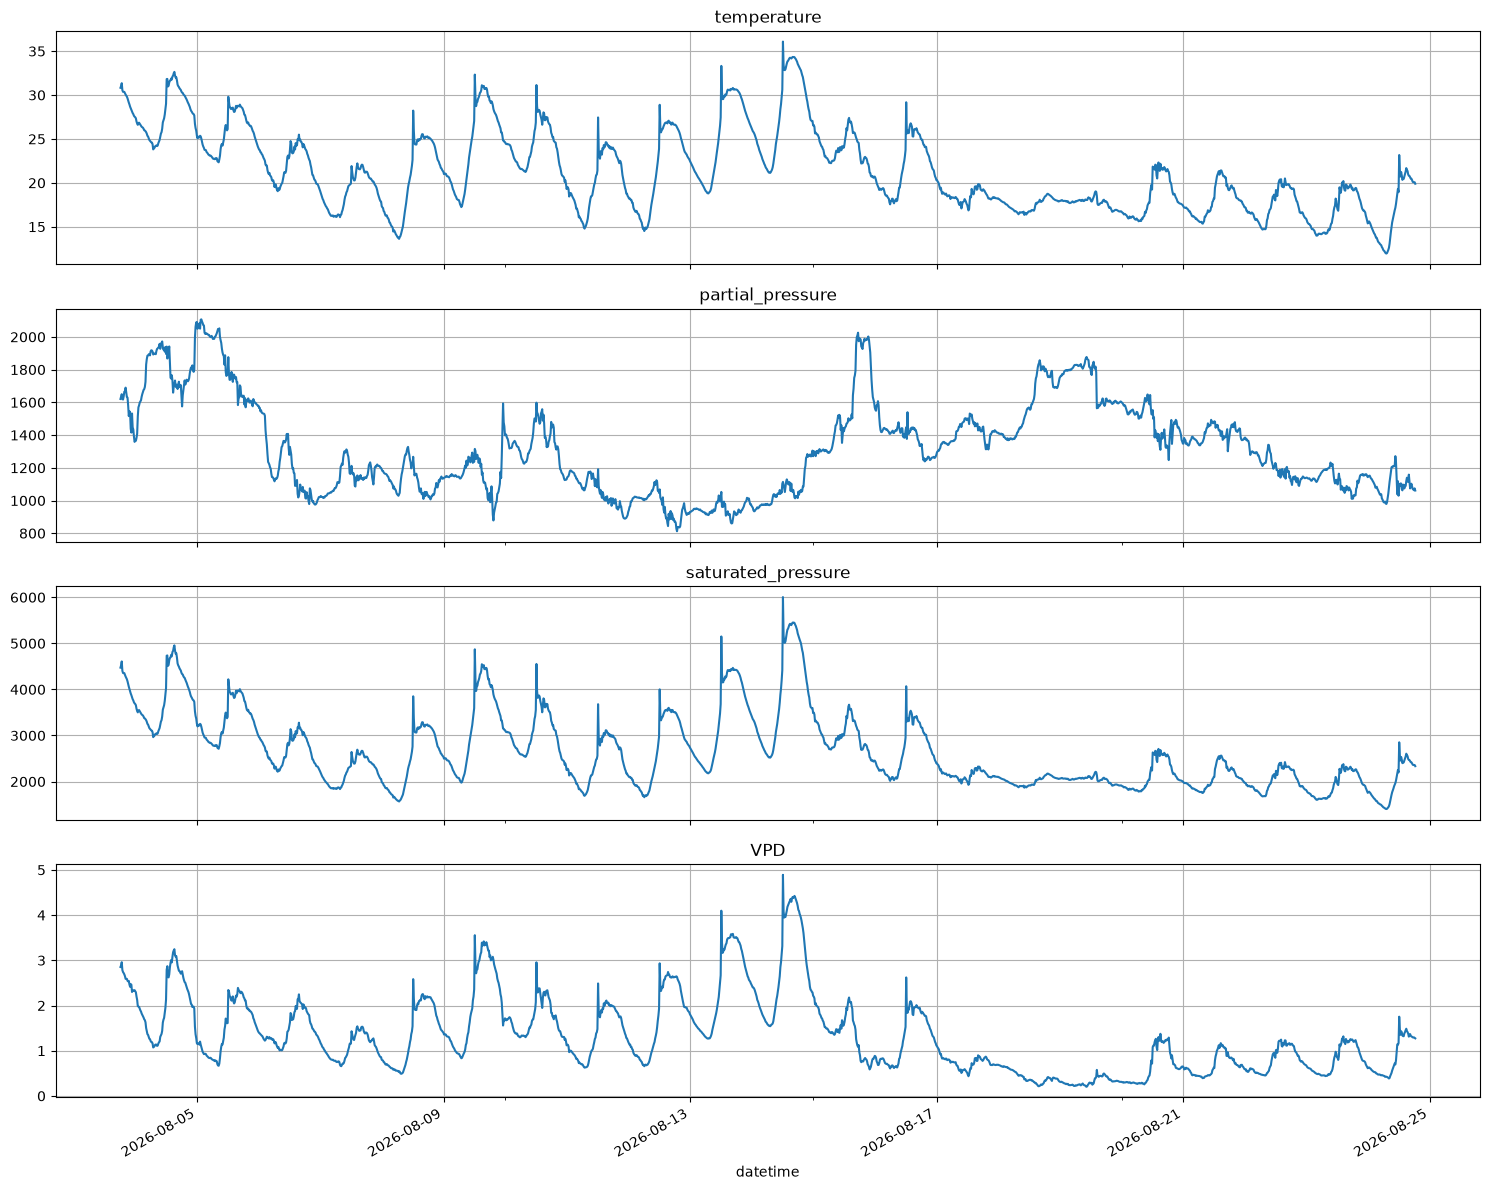

In [110]:
plot_cols(data_aug, ignore=['timestamp', 'humidity', 'pressure', 'pump_time', 'soil_moisture'])

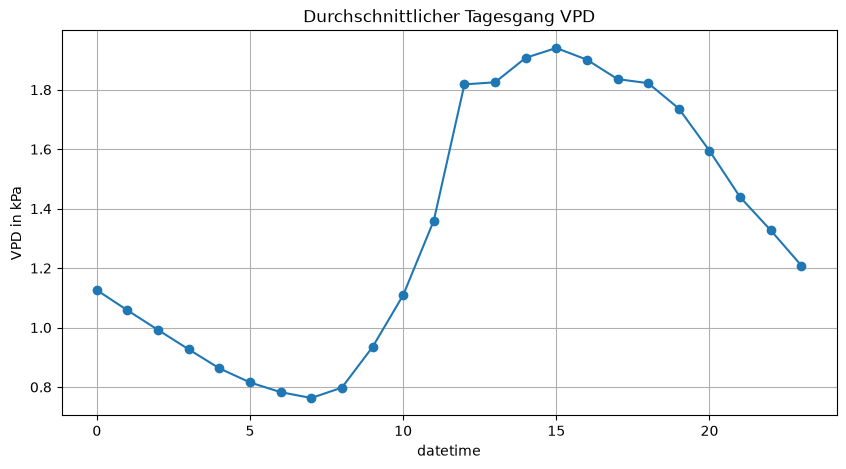

In [117]:
# Durchschnittlicher Tagesverlauf des VPD 
data_aug_vpd = data_aug.groupby(data_aug.index.hour)['VPD'].mean()
ax = data_aug_vpd.plot(figsize=(10,5), title='Durchschnittlicher Tagesgang VPD', marker='o')
ax.set_ylabel('VPD in kPa')
ax.grid(True)

# Motivation und Zielstellung
Mit dem beschriebenen Versuchsaufbau soll es später möglich sein die Wasserzufuhr sollwertgeführt zu automatisieren, um ein über- bzw. unterbewässern zu vermeiden und einen guten Ertrag aus dem Beet zu erwirtschaften. Aus einer länger andauernden Messung sollen die aufgenommenen Daten dabei helfen, geeignete Sollwerte zur Bewässerung zu definieren und eventuell Werte aus der Literatur zu validieren. Ein sekundäres Ziel könnte sein die gemessenen Umgebungswerte mit denen eines Wetterdienstes zu vergleichen und zu überprüfen, ob die eigene Messung dieser Werte notwendig ist oder auch die Messungen eines Wetterdienstes mit eventuell leicht abweichendem Standort ausreichend sind. 

geeignete Sollwerte ermitteln